In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/bariankitvinod/pr-pictures/Picture1.jpg
/kaggle/input/datasets/bariankitvinod/pr-pictures/Picture3.png
/kaggle/input/datasets/bariankitvinod/pr-pictures/Picture2.jpg


In [3]:
!pip install opencv-python ultralytics -q
!pip install "transformers<5.0.0" accelerate -q
!pip install pillow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 97.9 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.9 MB/s eta 0:00:00


### Image views

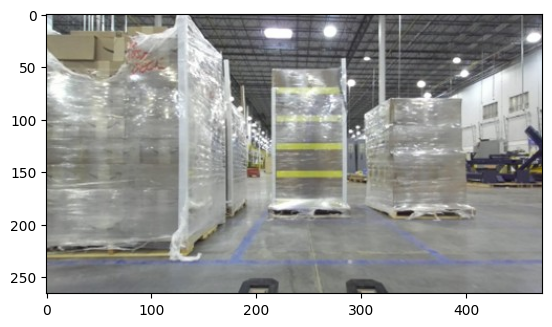

In [4]:
import cv2

# blue tape, without load pallet and with load pallet
pic1=cv2.imread('/kaggle/input/datasets/bariankitvinod/pr-pictures/Picture1.jpg')
# with load pallet, straight load, with glare
pic2=cv2.imread('/kaggle/input/datasets/bariankitvinod/pr-pictures/Picture2.jpg')
# without tape, slightly tilte load
pic3=cv2.imread('/kaggle/input/datasets/bariankitvinod/pr-pictures/Picture3.png')

def display(img):
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.show()

display(pic2)

### Image preprocessing

In [5]:
def preprocessing(img):
    frame=cv2.resize(img, (640, 480))
    
    LAB=cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
    L, A, B = cv2.split(LAB)

    clahe=cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    L = clahe.apply(L)

    frame = cv2.merge((L, A, B))
    frame=cv2.cvtColor(frame, cv2.COLOR_LAB2BGR)

    return frame

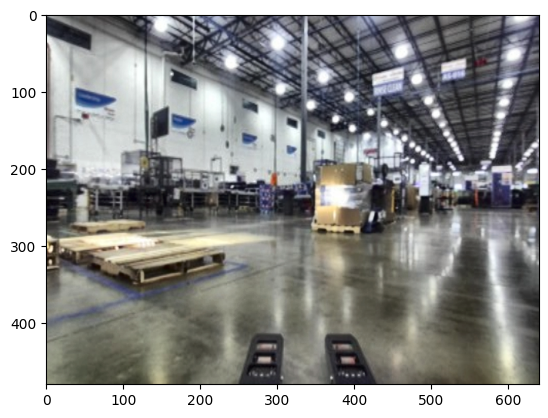

In [6]:
prepic1 = preprocessing(pic1)
prepic2 = preprocessing(pic2)
display(prepic1)

### Pallet detection

In [7]:
from ultralytics import YOLO
model = YOLO('yolov8n.pt')

def detect_pallet(frame):
    results = model(frame, device='cpu')[0]
    return results.plot()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.



0: 480x640 2 cell phones, 254.1ms
Speed: 7.6ms preprocess, 254.1ms inference, 24.3ms postprocess per image at shape (1, 3, 480, 640)


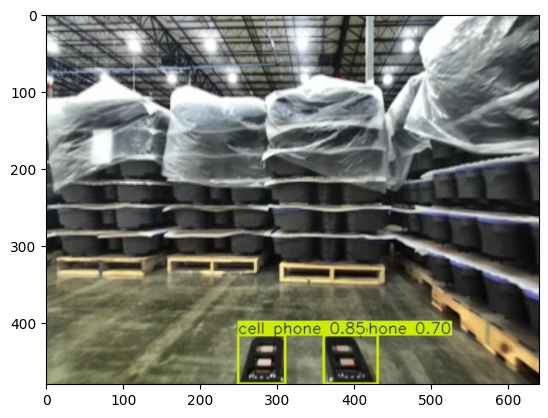

In [8]:
yolo=detect_pallet(preprocessing(pic3))
display(yolo)

### Above image can clearly conclude, our YOLOv8n fails to detect pallet. We need to fine-tune our YOLOv8n with 80-100 labeled images of pallet. [model.train()]

### Let after fine-tuning model will detecting pallets like this

pic1 pallet detected with confidence 0.9


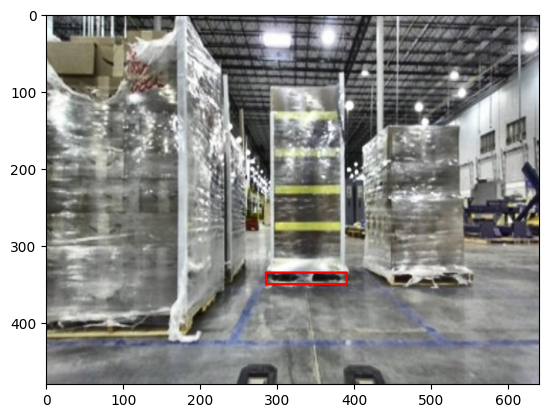

In [9]:
bbox = cv2.rectangle(prepic2, (285, 335), (390, 350), (0, 0, 255), 2)
conf = 0.90
print(f"pic1 pallet detected with confidence {conf}")
display(bbox)

### Tape detection

In [10]:
def detect_tape(frame):
    h, w = frame.shape[:2]
    roi=frame[int(h*0.75):, :]
    HSV=cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

    lower_blue=np.array([90, 80, 60])
    upper_blue=np.array([130, 255, 255])

    mask = cv2.inRange(HSV, lower_blue, upper_blue)
    # print(len(mask))
    tape=np.sum(mask>0)>100

    return tape, mask

Tape present: True


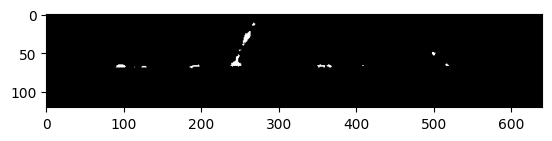

In [11]:
tape, mask = detect_tape(preprocessing(pic2))
print(f"Tape present: {tape}")
display(mask)

### Heuristic checks

In [12]:
def positioning(frame, pallet_bbox):

    # Step 1: detect tape
    tape_mask = detect_tape(frame)

    # -------------------------------
    # CASE 1: Tape Present
    # -------------------------------
    if tape_mask is not None and area(tape_mask) > MIN_TAPE_AREA:

        # Step 2: compute centers
        pallet_center = get_bbox_center(pallet_bbox)
        tape_center = get_mask_center(tape_mask)

        # Step 3: center alignment
        center_offset = abs(pallet_center.x - tape_center.x) / frame.width

        # Step 4: overlap area
        pallet_area = bbox_area(pallet_bbox)
        inside_area = compute_overlap(pallet_bbox, tape_mask)

        inside_ratio = inside_area / pallet_area

        # Step 5: decision
        if center_offset < 0.08 and inside_ratio > 0.85:
            return True
        else:
            return False

    # -------------------------------
    # CASE 2: No Tape
    # -------------------------------
    else:

        # Step 2: estimate angles
        pallet_angle = detect_pallet_angle(frame, pallet_bbox)
        fork_angle = detect_fork_orientation(frame, pallet_bbox)

        # Step 3: decision
        if abs(pallet_angle) < 5 and abs(fork_angle) < 5:
            return True
        else:
            return False

def isolation(frame, pallet_bbox, detections):

    # Step 1: define margin around pallet (15% of width)
    margin = 0.15 * bbox_width(pallet_bbox)

    # Step 2: check nearby objects
    nearby_objects = 0

    for obj in detections:
        if obj.class_name == "pallet":
            continue
        
        if is_within_margin(obj.bbox, pallet_bbox, margin):
            nearby_objects += 1

    # Step 3: check front region (approach path)
    front_roi = extract_front_region(frame, pallet_bbox, ratio=0.2)

    front_clear = is_region_clear(front_roi)

    # Step 4: final decision
    if nearby_objects == 0 and front_clear:
        return True
    else:
        return False

def accessibility(frame, pallet_bbox):

    # Step 1: estimate pallet tilt
    tilt_angle = estimate_tilt(frame, pallet_bbox)

    # Step 2: estimate heights
    pallet_height = get_pallet_height(pallet_bbox)
    load_height = estimate_load_height(frame, pallet_bbox)

    height_ratio = load_height / pallet_height

    # Step 3: decision
    if abs(tilt_angle) < 4 and height_ratio < 3:
        return True
    else:
        return False

def stability(frame, pallet_bbox):

    # Step 1: pallet center
    pallet_center_x = get_bbox_center(pallet_bbox).x

    # Step 2: extract load region (above pallet base)
    load_region = extract_load_region(frame, pallet_bbox)

    # Step 3: compute load center
    load_center_x = compute_center(load_region).x

    # Step 4: compute offset
    pallet_width = bbox_width(pallet_bbox)

    offset = abs(load_center_x - pallet_center_x) / pallet_width

    # Step 5: decision
    if offset < 0.12:
        return True
    else:
        return False

### Fork pocket detection

In [13]:
def detect_fork_pockets(frame, bbox):
    x1,y1,x2,y2 = bbox

    roi=frame[int(y2 - 0.25*(y2-y1)):y2, x1:x2]
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    
    _, thresh = cv2.threshold(gray, 60, 255, cv2.THRESH_BINARY_INV)
    
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if len(contours) >= 2:
        return gray, "CLEAR"
    else:
        return gray, "UNCERTAIN"

CLEAR


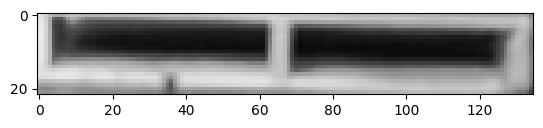

In [14]:
_, fork_pockets=detect_fork_pockets(preprocessing(pic3), [305, 265, 440, 350]) #[285, 290, 390, 350])
print(fork_pockets)
display(_)

### VLM

In [15]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_id = "vikhyatk/moondream2"

tokenizer = AutoTokenizer.from_pretrained(model_id)

device = "cuda" if torch.cuda.is_available() else "cpu"

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    trust_remote_code=True,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
).to(device)

model.eval()

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

...

A new version of the following files was downloaded from https://huggingface.co/vikhyatk/moondream2:
- utils.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/vikhyatk/moondream2:
- moondream.py
- lora.py
- image_crops.py
- vision.py
- utils.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/vikhyatk/moondream2:
- hf_moondream.py
- region.py
- text.py
- moondream.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
E0000 00:00:1777465310.220661      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register fac

model.safetensors:   0%|          | 0.00/3.85G [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

generation_config.json:   0%|          | 0.00/69.0 [00:00<?, ?B/s]

HfMoondream(
  (model): MoondreamModel(
    (vision): ModuleDict(
      (patch_emb): Linear(in_features=588, out_features=1152, bias=True)
      (blocks): ModuleList(
        (0-26): 27 x ModuleDict(
          (ln1): LayerNorm((1152,), eps=1e-05, elementwise_affine=True)
          (attn): ModuleDict(
            (qkv): Linear(in_features=1152, out_features=3456, bias=True)
            (proj): Linear(in_features=1152, out_features=1152, bias=True)
          )
          (ln2): LayerNorm((1152,), eps=1e-05, elementwise_affine=True)
          (mlp): ModuleDict(
            (fc1): Linear(in_features=1152, out_features=4304, bias=True)
            (fc2): Linear(in_features=4304, out_features=1152, bias=True)
          )
        )
      )
      (post_ln): LayerNorm((1152,), eps=1e-05, elementwise_affine=True)
      (proj_mlp): ModuleDict(
        (fc1): Linear(in_features=2304, out_features=8192, bias=True)
        (fc2): Linear(in_features=8192, out_features=2048, bias=True)
      )
    )
  

In [16]:
PROMPT_TEXT = """
You are an industrial robot perception system. Analyze the image of a warehouse pallet.

Answer the following questions in this exact JSON format and nothing else:

{
  "pallet_detected": true or false,
  "pallet_position": "centered" | "offset_left" | "offset_right" | "unknown",
  "staging_zone": "inside_tape" | "no_tape_visible" | "partially_inside",
  "clearance_around_pallet": "clear" | "obstructed" | "uncertain",
  "load_appears_stable": true or false,
  "glare_present": true or false,
  "ready_to_move": true or false,
  "reason": "<brief one-sentence explanation>"
}

Only output the JSON. Do not add any explanation before or after.
"""

In [17]:
from PIL import Image
import json
import re

In [18]:
def cv2_to_pil(frame):
    return Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

def prepare_for_vlm(frame, bbox):
    x1, y1, x2, y2 = map(int, bbox)
    
    crop = frame[y1:y2, x1:x2]

    crop = cv2.resize(crop, (336, 336))

    return crop

def parse_json(response):
    try:
        json_str = re.search(r"\{.*\}", response, re.DOTALL).group()
        return json.loads(json_str)
    except:
        return {
            "ready_to_move": False,
            "reason": "parse_error",
            "raw_output": response
        }

def run_vlm(frame_crop):
    image = cv2_to_pil(frame_crop)

    with torch.no_grad():
        enc_image = model.encode_image(image)

        response = model.answer_question(
            enc_image,
            PROMPT_TEXT,
            tokenizer,
            max_new_tokens=120
        )

    return parse_json(response)

def call_vlm(frame, bbox):
    crop = prepare_for_vlm(frame, bbox)
    return run_vlm(crop)

In [19]:
bbox, conf = [285, 290, 390, 350], conf

if bbox is not None:
    result = call_vlm(prepic2, bbox)
    print(json.dumps(result, indent=2))
else:
    print("No pallet detected")

{
  "pallet_detected": true,
  "pallet_position": "centered",
  "staging_zone": "inside_tape",
  "clearance_around_pallet": "clear",
  "load_appears_stable": true,
  "glare_present": true,
  "ready_to_move": true,
  "reason": "The pallet appears to be stable and ready for movement."
}


### Full Pipeline

In [20]:
def pipeline(frame):
    frame = preprocessing(frame) #preprocessing(frame)

    bbox, conf = [285, 290, 390, 350], 0.90 #detect_pallet(frame)

    if bbox is None:
        return "NOT_READY"

    tape_present, _ = detect_tape(frame) #detect_tape(frame)

    positioning = True #check_positioning()
    isolation = True #check_isolation()
    accessibility = True #check_accessibility()
    stability = True #check_stability()

    _, pocket_status = detect_fork_pockets(frame, bbox) #detect_fork_pockets(frame, bbox)
    # display(_)
    # print(pocket_status)

    ready = (
        positioning and
        isolation and
        accessibility and
        stability and
        pocket_status == "CLEAR" # CLEAR UNCERTAIN
    )

    if not ready:
        vlm = call_vlm(frame, bbox) # ask VLM
        # print(vlm)
        ready = vlm["ready_to_move"]

    return "READY" if ready else "NOT_READY"

In [22]:
print(f"Peer-3000 : {pipeline(pic2)}")

Peer-3000 : READY
